# He4 - nonlocal regulator 2-6-6 system

Last edited 2024-08-24 Lucas Platter

* Generating the RG flow with the physical $C_6$

Import relevant packages

In [16]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt
import mu2
import scienceplots
from scipy.optimize import fsolve
import helium4plusplusphysical as he4
plt.style.use('science')
gr = 4/3
h = 3

In [2]:
phaseshifts_lm2m2 = np.loadtxt('datfiles/lm2m2_swave_phase_shifts.txt')

In [3]:
def crosssection(phaseshift,momentum):
    return (np.sin(phaseshift)**2)

In [4]:
plotsize = 2
plt.rcParams['figure.figsize'] = [1.618*plotsize,plotsize]
plt.rcParams['figure.dpi'] = 200

Set parameters and load LO RG flow:

In [5]:
# angular momentum
ELL = 0
# load lo coupling constants
Rs, gs = np.loadtxt('datfiles/he4plusplus_LO_nonlocal2_2_6_6_rg_flow.txt', unpack=True)
#Rs, gs = np.loadtxt('rg_flow_lo_nonlocal_2_6_6.txt', unpack=True)
# number of short distance cutoffs
nR = Rs.size

N1 = 2
N2 = 6
NCT = 6

In [6]:
he4.C6

10130.537638625547

In [7]:
# momentum grid
momenta = np.linspace(0.01/he4.BETA6, 0.3/he4.BETA6, 70)

# scale to render g dimensionless
X = he4.FACTOR * he4.BETA6 # K•Å^3

# kcotd delta returned from a and r
KCD = -1/he4.A0 + he4.R0/2*momenta**2

# First, we will tune k(cot(delta)). Then we'll go back and refine a_0 and r_0.
def kcd_diff(gpair, sys):
    kcd = sys.kcotd_gen_pert1_fast(momenta, *gpair)
    return np.sum(((KCD - kcd)/KCD)**2)

In [8]:
?s.kcotd_gen_fast

Object `s.kcotd_gen_fast` not found.


In [9]:
def a0_diff(gi, gj, sys):
    a0, _ = sys.a0_and_r0_pert1_fast(gi,gj,momenta)
    return (he4.A0 - a0)/he4.A0

## LO RG flow

In [10]:
R_MAX = he4.BETA6/2
R_MIN = he4.BETA6/25

nLO = 1000
R_LO = 2/np.linspace(2/R_MAX, 2/R_MIN, nLO)

gsLO = np.zeros(nLO)
b2sLO = np.zeros(nLO)
r0sLO = np.zeros(nLO)

In [11]:
def inverse_a0_diff_lo(g, sys):
    a0, _ = sys.a0_and_r0(g, 0, momenta, use_c=True)
    return (1/he4.A0 - 1/a0)*he4.A0

In [12]:
N1 = 2
N2 = 6
NCT = 6

R=R_LO[0]
print('R=',R)
s = he4.NonlocalHelium4System2(R, ELL, N1, N2, NCT)

R= 2.6884930808114067


In [13]:
0.0345*X

2.2481994292847087

In [14]:
guess = 0.0345*X
s.a0_and_r0(guess, 0, momenta, use_c=True), s.bound_state_spectrum(guess, 0)

((97.41134118941993, 6.280297252195384), array([-0.00136714]))

In [14]:
for i in range(nLO):
    R = R_LO[i]
    s = he4.NonlocalHelium4System2(R, ELL, N1, N2, NCT)
    result = optimize.fsolve(inverse_a0_diff_lo, guess, args=(s), factor=0.1)
    g = result[0]
    a0, r0 = s.a0_and_r0(g, 0, momenta)
    
    if np.abs((he4.A0 - a0)/he4.A0) < 1e-4:
        e2s = s.bound_state_spectrum(g, 0)
        gsLO[i] = g
        r0sLO[i] = r0
        b2sLO[i] = np.abs(e2s[0])
        print(f'i = {i}  R = {R}  g = {g/X:.4e} X  a0 = {a0:.4e}  r0 = {r0:.4e}  b2 = {np.abs(e2s[0])}')
    else:
        break

i = 0  R = 2.6884930808114067  g = 3.5039e-02 X  a0 = 1.0000e+02  r0 = 6.2901e+00  b2 = 0.0012950206766432768
i = 1  R = 2.6578966726675852  g = 5.3876e-02 X  a0 = 1.0000e+02  r0 = 6.3481e+00  b2 = 0.0012959003085173978
i = 2  R = 2.627988833395886  g = 7.3313e-02 X  a0 = 1.0000e+02  r0 = 6.4051e+00  b2 = 0.001296767423964842
i = 3  R = 2.598746577388094  g = 9.3397e-02 X  a0 = 1.0000e+02  r0 = 6.4611e+00  b2 = 0.0012976201394744086
i = 4  R = 2.5701479308426745  g = 1.1418e-01 X  a0 = 1.0000e+02  r0 = 6.5158e+00  b2 = 0.00129845665356585
i = 5  R = 2.5421718766972035  g = 1.3572e-01 X  a0 = 1.0000e+02  r0 = 6.5693e+00  b2 = 0.0012992752540284024
i = 6  R = 2.5147983031185346  g = 1.5807e-01 X  a0 = 1.0000e+02  r0 = 6.6213e+00  b2 = 0.0013000743224583714
i = 7  R = 2.488007955285405  g = 1.8131e-01 X  a0 = 1.0000e+02  r0 = 6.6719e+00  b2 = 0.0013008523421074673
i = 8  R = 2.4617823902205274  g = 2.0551e-01 X  a0 = 1.0000e+02  r0 = 6.7209e+00  b2 = 0.0013016079012493143
i = 9  R = 2.436

/var/folders/ck/pyzk3f1d493gs81zvyyvkgmw0000gn/T/ipykernel_22115/585533307.py:4: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  result = optimize.fsolve(inverse_a0_diff_lo, guess, args=(s), factor=0.1)


In [241]:
restart = 940
s = he4.NonlocalHelium4System2(R_LO[restart], ELL, N1, N2, NCT)

In [259]:
guess = -1850*X
s.a0_and_r0(guess, 0, momenta, use_c=True), s.bound_state_spectrum(guess, 0)

((100.27478106405482, 7.10052326332445),
 array([-1.30003739e-03, -7.53716096e+01, -7.08813583e+02, -4.35876990e+03,
        -3.40147879e+04, -5.22069164e+05, -1.92526813e+07]))

In [260]:
for i in range(restart, nLO):
    R = R_LO[i]
    s = he4.NonlocalHelium4System2(R, ELL, N1, N2, NCT)
    result = optimize.fsolve(inverse_a0_diff_lo, guess, args=(s), factor=0.1)
    g = result[0]
    a0, r0 = s.a0_and_r0(g, 0, momenta)
    
    if np.abs((he4.A0 - a0)/he4.A0) < 1e-4:
        e2s = s.bound_state_spectrum(g, 0)
        gsLO[i] = g
        r0sLO[i] = r0
        b2sLO[i] = np.abs(e2s[0])
        print(f'i = {i}  R = {R:.4f}  g = {g/X:.4e} X  a0 = {a0:.4e}  r0 = {r0:.4e}  b2 = {np.abs(e2s[0])}')
    else:
        break

i = 940  R = 0.2274  g = -1.8641e+03 X  a0 = 1.0000e+02  r0 = 7.0995e+00  b2 = 0.0013074623786556256
i = 941  R = 0.2272  g = -7.6228e+02 X  a0 = 1.0000e+02  r0 = 7.0995e+00  b2 = 0.0013074616845675795
i = 942  R = 0.2270  g = -4.6686e+02 X  a0 = 1.0000e+02  r0 = 7.0994e+00  b2 = 0.0013074609858340794
i = 943  R = 0.2268  g = -3.2964e+02 X  a0 = 1.0000e+02  r0 = 7.0994e+00  b2 = 0.0013074603004431925
i = 944  R = 0.2266  g = -2.5032e+02 X  a0 = 1.0000e+02  r0 = 7.0993e+00  b2 = 0.0013074596209836854
i = 945  R = 0.2263  g = -1.9861e+02 X  a0 = 1.0000e+02  r0 = 7.0993e+00  b2 = 0.0013074589578013615
i = 946  R = 0.2261  g = -1.6220e+02 X  a0 = 1.0000e+02  r0 = 7.0993e+00  b2 = 0.0013074583069886767
i = 947  R = 0.2259  g = -1.3515e+02 X  a0 = 1.0000e+02  r0 = 7.0992e+00  b2 = 0.0013074576662764242
i = 948  R = 0.2257  g = -1.1425e+02 X  a0 = 1.0000e+02  r0 = 7.0992e+00  b2 = 0.0013074570445465127
i = 949  R = 0.2255  g = -9.7603e+01 X  a0 = 1.0000e+02  r0 = 7.0991e+00  b2 = 0.0013074564

Text(0, 0.5, '$g_{\\rm LO}$')

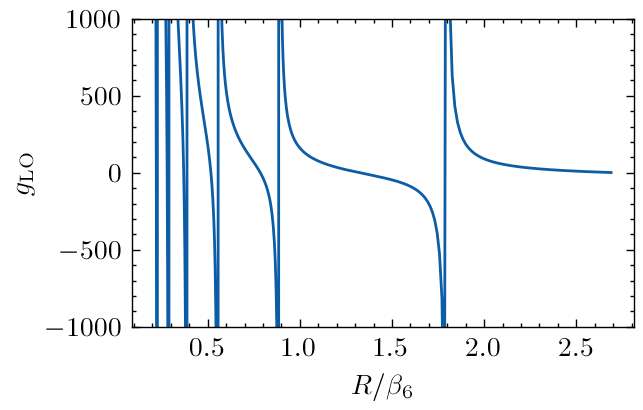

In [261]:
plt.plot(R_LO, gsLO)
plt.ylim(-1000,1000)
plt.xlabel('$R/\\beta_6$')
plt.ylabel('$g_{\\rm LO}$')

In [262]:
np.savetxt('rg_flow_lo_nonlocal_2_6_6-physicalC6.txt', np.vstack((R_LO, gsLO)).T, header='R (Å)  g ()')

In [9]:
R_LO, gsLO = np.loadtxt('rg_flow_lo_nonlocal_2_6_6-physicalC6.txt',unpack=True)

In [10]:
len(R_LO)

1000

## NLO perturbative w/ subleading momentum independent counterterm

Now we are optimizing to the effective range expansion with the range included!

In [11]:
# First, we will tune k(cot(delta)). Then we'll go back and refine a_0 and r_0.
def kcd_diff(c_2s, sys, c_00):
    kcd = sys.kcotd_gen_pert1b_fast(momenta, c_00, *c_2s)
    return np.sum(((KCD - kcd)/KCD)**2)

def a0_diff(c_2s, sys, c_00):
    a0, r0 = sys.a0_and_r0_pert1b_fast(c_00, *c_2s, momenta)
    return he4.A0*(1/he4.A0 - 1/a0)

In [12]:
from scipy.optimize import minimize

In [13]:
R_LO = np.float32(R_LO)

In [14]:
gsLO = np.float32(gsLO)

In [15]:
result = minimize(lambda x: kcd_diff([-1,x], s, gsLO[0]),1)

NameError: name 's' is not defined

In [26]:
N = 502
print(R_LO[N])
print(gsLO[N])
print('{:.17}'.format(R_LO[N]))

0.39660433
2709.7842
0.39660432934761047


In [30]:
index = N
s = he4.NonlocalHelium4System2(R_LO[index], ELL, N1, N2, NCT)
#nlo_guess = result.x
c20 = -49609.74443706987
test = np.linspace(-280000,-560000,1400)

for i in range(len(test)):
#    result = minimize(lambda x: a0_diff([x,test[i]],s, gsLO[index]),-0.1,tol=1e-6)
    result = optimize.fsolve(lambda x: a0_diff([x,test[i]],s, gsLO[index]), c20,xtol=1e-8)
    c2s = np.array([*result, test[i]])
    atemp, rtemp= s.a0_and_r0_pert1b_fast(gsLO[index], *c2s, momenta)
    print(R_LO[index], gsLO[index],c2s[0],c2s[1],atemp,rtemp)
    c20 = c2s[0]+0.01*np.abs(c2s[0])

0.39660433 2709.7842 -49609.744437088346 -280000.0 99.99999999478399 7.246132514451275
0.39660433 2709.7842 -49645.205292921535 -280200.1429592566 100.0000000033336 7.246223585911293
0.39660433 2709.7842 -49680.666148745746 -280400.2859185132 100.00000000263348 7.246314671050317
0.39660433 2709.7842 -49716.12700460365 -280600.42887776985 100.00000001465042 7.246405730474388
0.39660433 2709.7842 -49751.58786041952 -280800.57183702645 100.0000000139164 7.246496817234383
0.39660433 2709.7842 -49787.04871627811 -281000.71479628305 99.99999999740172 7.246587901725431
0.39660433 2709.7842 -49822.509572110015 -281200.85775553965 99.99999999234181 7.2466789878840725
0.39660433 2709.7842 -49857.970427938635 -281401.0007147963 100.00000001142715 7.246770051900217
0.39660433 2709.7842 -49893.43128381144 -281601.1436740529 99.99999999626867 7.2468611313434135
0.39660433 2709.7842 -49928.89213966184 -281801.2866333095 99.99999999549449 7.246952204481202
0.39660433 2709.7842 -49964.35299546182 -2820

0.39660433 2709.7842 -52659.37803988738 -297212.2944960686 99.99999998629124 7.25396459812488
0.39660433 2709.7842 -52694.838895692956 -297412.4374553252 100.00000001105617 7.254055654461716
0.39660433 2709.7842 -52730.29975159539 -297612.58041458187 100.00000000250907 7.254146709456163
0.39660433 2709.7842 -52765.76060741915 -297812.72337383847 99.99999999488647 7.2542377894749315
0.39660433 2709.7842 -52801.22146329017 -298012.86633309507 99.99999999082418 7.254328850349436
0.39660433 2709.7842 -52836.68231912732 -298213.00929235166 99.99999999970824 7.2544199111952965
0.39660433 2709.7842 -52872.14317499705 -298413.1522516083 100.00000000624955 7.2545109614695775
0.39660433 2709.7842 -52907.604030854396 -298613.2952108649 100.00000000707604 7.254602022539797
0.39660433 2709.7842 -52943.06488668619 -298813.4381701215 100.000000002632 7.25469309524487
0.39660433 2709.7842 -52978.52574257011 -299013.5811293781 100.00000000151458 7.254784149925198
0.39660433 2709.7842 -53013.98659838048

0.39660433 2709.7842 -55709.01164366978 -314424.5889921372 99.99999999381951 7.261795485240356
0.39660433 2709.7842 -55744.472499562966 -314624.7319513939 99.9999999868996 7.261886530056515
0.39660433 2709.7842 -55779.93335539755 -314824.8749106505 100.00000000225982 7.261977577486984
0.39660433 2709.7842 -55815.39421123688 -315025.0178699071 100.00000000640333 7.262068631790551
0.39660433 2709.7842 -55850.85506713936 -315225.1608291637 99.99999998824664 7.2621596854161306
0.39660433 2709.7842 -55886.3159229901 -315425.3037884203 99.99999999371069 7.262250735213311
0.39660433 2709.7842 -55921.776778854 -315625.44674767694 99.99999999480039 7.262341781307174
0.39660433 2709.7842 -55957.23763471575 -315825.58970693353 99.99999999892006 7.262432828061995
0.39660433 2709.7842 -55992.69849059687 -316025.73266619013 100.00000000687533 7.262523862107935
0.39660433 2709.7842 -56028.15934645015 -316225.87562544673 100.00000000596678 7.262614917104482
0.39660433 2709.7842 -56063.62020229526 -316

0.39660433 2709.7842 -58758.64524846943 -331636.88348820584 100.00000000490905 7.269625177385085
0.39660433 2709.7842 -58794.10610437122 -331837.0264474625 99.99999998282311 7.269716225562771
0.39660433 2709.7842 -58829.56696023946 -332037.1694067191 99.99999999958439 7.269807248553604
0.39660433 2709.7842 -58865.02781613432 -332237.3123659757 99.99999998623527 7.269898288693643
0.39660433 2709.7842 -58900.488671994775 -332437.4553252323 99.99999999094753 7.269989325269243
0.39660433 2709.7842 -58935.94952785744 -332637.5982844889 99.99999999467086 7.270080364245669
0.39660433 2709.7842 -58971.410383759125 -332837.74124374555 99.99999998760609 7.270171395902194
0.39660433 2709.7842 -59006.871239620246 -333037.88420300215 100.00000000169888 7.270262425682617
0.39660433 2709.7842 -59042.332095496386 -333238.02716225875 99.99999999536695 7.270353463104793
0.39660433 2709.7842 -59077.792951390555 -333438.1701215154 100.00000001154156 7.270444478533852
0.39660433 2709.7842 -59113.2538072386

0.39660433 2709.7842 -61808.27885430928 -348849.17798427446 99.9999999967007 7.277453687997981
0.39660433 2709.7842 -61843.739710212714 -349049.3209435311 99.99999999846143 7.277544704944736
0.39660433 2709.7842 -61879.20056607169 -349249.4639027877 99.99999999226951 7.277635741088427
0.39660433 2709.7842 -61914.66142198074 -349449.6068620443 99.99999999397141 7.27772675434984
0.39660433 2709.7842 -61950.12227785523 -349649.74982130097 100.00000000535343 7.277817771214943
0.39660433 2709.7842 -61985.5831337774 -349849.89278055757 99.99999999789497 7.277908787497899
0.39660433 2709.7842 -62021.043989625 -350050.03573981416 100.00000000413505 7.27799981625756
0.39660433 2709.7842 -62056.50484553929 -350250.17869907076 99.99999999486852 7.278090837647799
0.39660433 2709.7842 -62091.96570140814 -350450.32165832736 99.9999999963272 7.278181864819121
0.39660433 2709.7842 -62127.42655727401 -350650.464617584 99.99999999958006 7.278272888807139
0.39660433 2709.7842 -62162.88741320067 -350850.6

...

0.39660433 2709.7842 -83155.71412309546 -469335.2394567549 100.000000003711 7.332220222909659
0.39660433 2709.7842 -83568.40126394182 -469535.3824160114 100.00000063231796 -46.88684663698566
0.39660433 2709.7842 -83226.63583501447 -469735.5253752681 100.00000000835342 7.332402076924568
0.39660433 2709.7842 -83639.32324895197 -469935.6683345247 100.00000012658751 -46.88680758425445
0.39660433 2709.7842 -83297.55754696339 -470135.81129378127 100.00000000292982 7.332583930084228
0.39660433 2709.7842 -83710.24523517859 -470335.9542530379 100.0000007909966 -46.88676930889032
0.39660433 2709.7842 -83368.47925892404 -470536.09721229447 99.99999999299014 7.332765782630461
0.39660433 2709.7842 -83781.16721656254 -470736.2401715511 100.00000059361095 -46.88673051305322
0.39660433 2709.7842 -83439.40097082057 -470936.3831308077 100.00000000707705 7.332947635386255
0.39660433 2709.7842 -83852.08919739678 -471136.5260900643 99.99999848645734 -46.886690670564896
0.39660433 2709.7842 -83510.322682775

0.39660433 2709.7842 -86205.34773690297 -486547.5339528235 99.99999999523513 7.340039331702869
0.39660433 2709.7842 -86618.04655060367 -486747.67691208003 100.00000041641269 -46.88518439387726
0.39660433 2709.7842 -86276.26944886064 -486947.8198713367 99.99999999206574 7.340221160532606
0.39660433 2709.7842 -86688.96853544394 -487147.9628305933 99.99999947649238 -46.88514493131176
0.39660433 2709.7842 -86347.19116081238 -487348.1057898499 99.99999999356356 7.340402985948514
0.39660433 2709.7842 -86759.89051883073 -487548.24874910654 100.0000002231391 -46.88510679455927
0.39660433 2709.7842 -86418.11287277016 -487748.39170836314 100.00000000194706 7.340584806028217
0.39660433 2709.7842 -86830.81250401831 -487948.53466761974 100.00000071520856 -46.88506870319507
0.39660433 2709.7842 -86489.0345847302 -488148.67762687634 100.00000000725319 7.340766623103775
0.39660433 2709.7842 -86901.73448608961 -488348.82058613293 99.99999979711892 -46.885029286088795
0.39660433 2709.7842 -86559.9562967

0.39660433 2709.7842 -89254.98135167881 -503759.8284488921 100.0000000044959 7.347857265899534
0.39660433 2709.7842 -89667.6918401221 -503959.97140814865 99.99999907043765 -46.88352114528331
0.39660433 2709.7842 -89325.90306366209 -504160.1143674053 100.00000000225499 7.3480390653571
0.39660433 2709.7842 -89738.61382478724 -504360.2573266619 100.0000003660184 -46.88348330537771
0.39660433 2709.7842 -89396.82477562694 -504560.4002859185 100.00000000459738 7.3482208683226595
0.39660433 2709.7842 -89809.5358074248 -504760.54324517515 100.00000015717103 -46.8834444866499
0.39660433 2709.7842 -89467.74648762557 -504960.68620443175 99.99999999983298 7.348402664082178
0.39660433 2709.7842 -89880.45779201826 -505160.82916368835 100.0000004013664 -46.883405992532836
0.39660433 2709.7842 -89538.668199577 -505360.972122945 100.00000000494444 7.348584468889596
0.39660433 2709.7842 -89951.3797733766 -505561.11508220155 99.9999991890312 -46.88336666368843
0.39660433 2709.7842 -89609.58991158911 -505

0.39660433 2709.7842 -92304.61496743203 -520972.1229449607 100.0000000081809 7.355674044335543
0.39660433 2709.7842 -92717.33713022232 -521172.2659042173 99.99999999475803 -46.88185945933611
0.39660433 2709.7842 -92375.5366794469 -521372.4088634739 99.9999999948978 7.355855824484702
0.39660433 2709.7842 -92788.25911414175 -521572.5518227306 99.99999985557419 -46.88182065070903
0.39660433 2709.7842 -92446.45839146325 -521772.6947819871 99.999999991043 7.356037595682664
0.39660433 2709.7842 -92859.1810992034 -521972.83774124377 100.00000084022743 -46.88178276693837
0.39660433 2709.7842 -92517.38010343818 -522172.98070050037 100.00000001702742 7.356219356087364
0.39660433 2709.7842 -92930.10308093508 -522373.12365975697 99.99999930210797 -46.88174291888145
0.39660433 2709.7842 -92588.30181544277 -522573.2666190136 100.00000000088235 7.356401138719799
0.39660433 2709.7842 -93001.02506508339 -522773.40957827016 99.9999999640894 -46.881704716393486
0.39660433 2709.7842 -92659.22352748904 -52

KeyboardInterrupt: 

Plot the RG flow:

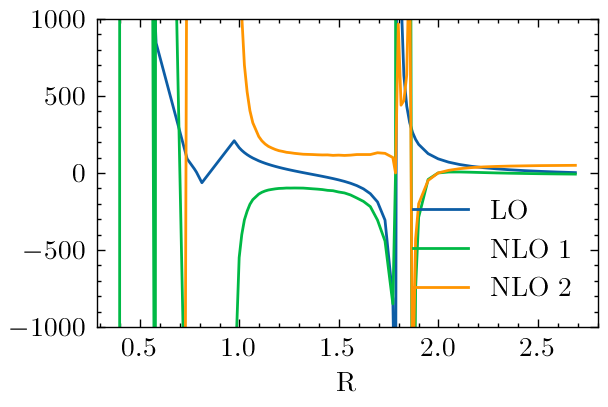

In [31]:
rgflowPhysicalC6 = np.loadtxt('/Users/lplatter/rg-nlo-physicalC6.txt',delimiter=' ',skiprows = 1)
plt.plot(rgflowPhysicalC6[:,0],rgflowPhysicalC6[:,1],label = 'LO')
plt.plot(rgflowPhysicalC6[:,0],rgflowPhysicalC6[:,2], label = 'NLO 1')
plt.plot(rgflowPhysicalC6[:,0],rgflowPhysicalC6[:,3], label = 'NLO 2')
plt.xlabel('R')
plt.ylim(-1000,1000)
plt.legend()

In [48]:
B3data=np.loadtxt("/Users/lplatter/En-3B-vdW-alt-64-32-lmax2.dat")

In [52]:
he4.BETA6

5.376986161622813

Text(0.5, 0, '$\\beta_6/R$')

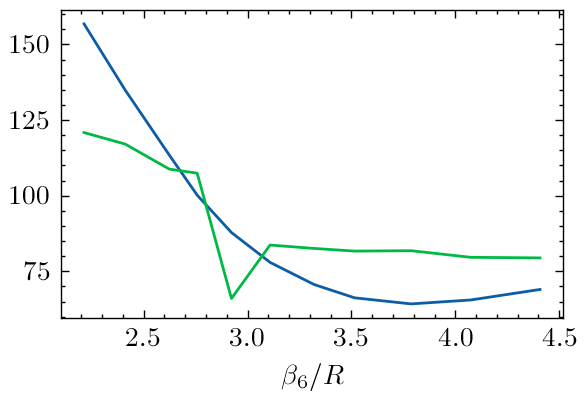

In [51]:
plt.plot(B3data[:,0],1000.*B3data[:,1])
plt.plot(he4.BETA6/B3data[:,0],1000.*(B3data[:,1]+B3data[:,2]))
plt.xlabel('$\\beta_6/R$')

In [9]:
B3Sdata = np.loadtxt("/Users/lplatter/projects/vdw-nlo/sebastian-data.txt")
B3SDdata = np.loadtxt("/Users/lplatter/projects/vdw-nlo/sebastian-data-S+D.txt")

Text(0.5, 0, '$\\beta_6/R$')

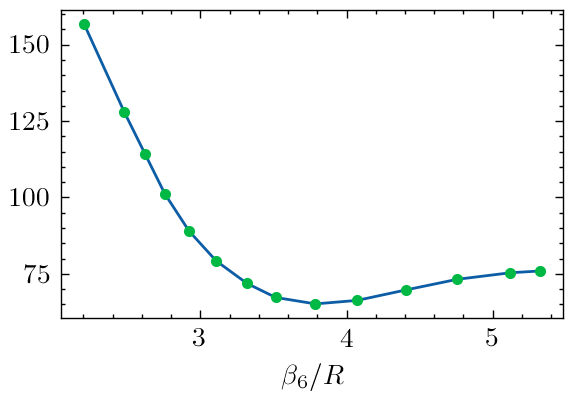

In [14]:
plt.plot(he4.BETA6/B3Sdata[:,0],1000*B3Sdata[:,1])
plt.plot(he4.BETA6/B3SDdata[:,0],1000*B3SDdata[:,1],'.')
plt.xlabel('$\\beta_6/R$')

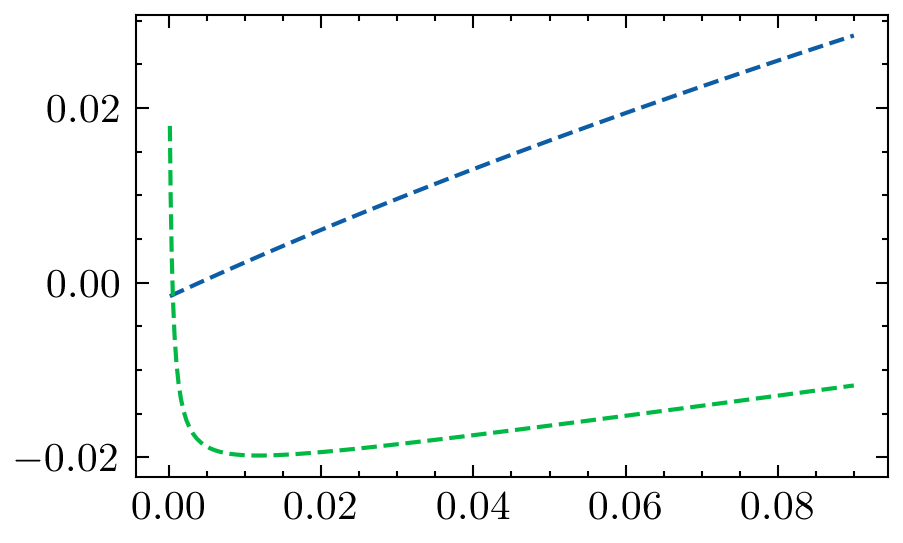

In [44]:
fig, ax = plt.subplots(dpi=300)
fig.patch.set_facecolor('white')

ax.plot((momenta*he4.BETA6)**2, s.kcotd_gen_pert1b_fast(momenta, gsLO[40],-6795.0817412325105 ,-2000.0 ), linestyle='--');
ax.plot((momenta*he4.BETA6)**2, s.kcotd_gen_pert1b_fast(momenta, gsLO[40],-7543.311999201044 ,-1928.5714285714287 ), linestyle='--');

In [17]:
he4.BETA6

5.376986161622813

In [398]:
optimize.fsolve(lambda x: a0_diff([x,4],s, gsLO[index]), -2.,xtol=1e-8)

array([-2.35557401])

In [393]:
a0_diff([-1.836,4],s, gsLO[0])

-1.3200592922481007

In [15]:
s.a0_and_r0_pert1b_fast(gsLO[0],-2.35557401,4, momenta)

(21.43614436044135, 28.616997960778033)